In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, make_scorer, roc_curve
import time
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)




# **Scikit-learn**


In [3]:
df_final = pd.read_csv('data/df_final.csv')

## *Preprocesamiento*

In [4]:
categorical_cols = df_final.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['term', 'sub_grade', 'home_ownership', 'verification_status', 'issue_d',
       'purpose', 'earliest_cr_line', 'application_type'],
      dtype='object')


In [5]:
df_final[['term', 'sub_grade', 'home_ownership', 'verification_status', 'issue_d',
       'purpose', 'earliest_cr_line', 'application_type']].head(10)

,term,sub_grade,home_ownership,verification_status,issue_d,purpose,earliest_cr_line,application_type
0,36 months,C4,MORTGAGE,Not Verified,Dec-2015,debt_consolidation,Aug-2003,Individual
1,36 months,C1,MORTGAGE,Not Verified,Dec-2015,small_business,Dec-1999,Individual
2,60 months,B4,MORTGAGE,Not Verified,Dec-2015,home_improvement,Aug-2000,Joint App
3,60 months,F1,MORTGAGE,Source Verified,Dec-2015,major_purchase,Jun-1998,Individual
4,36 months,C3,RENT,Source Verified,Dec-2015,debt_consolidation,Oct-1987,Individual
5,36 months,B2,MORTGAGE,Not Verified,Dec-2015,debt_consolidation,Jun-1990,Individual
6,36 months,B1,MORTGAGE,Not Verified,Dec-2015,major_purchase,Feb-1999,Individual
7,36 months,A2,RENT,Not Verified,Dec-2015,credit_card,Apr-2002,Individual
8,36 months,B5,MORTGAGE,Not Verified,Dec-2015,credit_card,Nov-1994,Individual
9,36 months,C2,MORTGAGE,Not Verified,Dec-2015,other,Jun-1996,Individual


### *Conversiones manuales*

1. Variable: `term`

In [6]:
# Eliminar la palabra "months" y espacios, dejando solo el número
df_final['term'] = df_final['term'].str.replace(' months', '', regex=False)

# Convertir a float
df_final['term'] = df_final['term'].astype(float)

print(df_final['term'].unique())
print(df_final['term'].dtype)

[36. 60.]
float64


2. Variable: `subgrade`

In [7]:
# Obtener la lista de valores únicos de 'sub_grade' y ordenarla
sorted_sub_grades = sorted(df_final['sub_grade'].unique())

# Crear un diccionario de mapeo
sub_grade_mapping = {sub_grade: i for i, sub_grade in enumerate(sorted_sub_grades)}

# Aplicar el mapeo a la columna 'sub_grade'
df_final['sub_grade'] = df_final['sub_grade'].map(sub_grade_mapping)

# Verificar el resultado y el tipo de dato
print("Valores únicos en la columna 'sub_grade' después del mapeo:")
print(df_final['sub_grade'].value_counts())
print("\nTipo de dato de la columna 'sub_grade':", df_final['sub_grade'].dtype)

Valores únicos en la columna 'sub_grade' después del mapeo:
sub_grade
10    85494
8     83199
9     82538
7     81827
11    79213
12    74998
13    74421
6     74024
5     71153
14    67560
4     64003
3     52235
15    51321
16    44848
0     43678
17    39317
2     37996
1     37178
18    35566
19    29901
20    23749
21    21377
22    18387
23    15720
24    14417
25     9970
26     7198
27     6088
28     4859
29     3943
30     2997
31     2131
32     1614
33     1280
34     1110
Name: count, dtype: int64

Tipo de dato de la columna 'sub_grade': int64


3. Variable: `earliest_cr_line`

In [8]:
# 1. Convertir 'earliest_cr_line' y 'issue_d' a formato de fecha y hora
df_final['earliest_cr_line'] = pd.to_datetime(df_final['earliest_cr_line'], format='%b-%Y')
df_final['issue_d'] = pd.to_datetime(df_final['issue_d'], format='%b-%Y')

# 2. Calcular la antigüedad del historial crediticio en meses
df_final['historial_crediticio_meses'] = (
    (df_final['issue_d'].dt.year - df_final['earliest_cr_line'].dt.year) * 12 +
    (df_final['issue_d'].dt.month - df_final['earliest_cr_line'].dt.month)
)

# 3. Eliminar las columnas de fecha originales
df_final = df_final.drop(columns=['earliest_cr_line', 'issue_d'])

# 4. Verificar el resultado
print("Variable 'historial_crediticio_meses' creada:")
print(df_final['historial_crediticio_meses'].head())
print("\nTipo de dato de la nueva columna:", df_final['historial_crediticio_meses'].dtype)

Variable 'historial_crediticio_meses' creada:
0    148
1    192
2    184
3    210
4    338
Name: historial_crediticio_meses, dtype: int32

Tipo de dato de la nueva columna: int32


### *Codificación y escalado*

In [9]:
# 1. Separar las variables predictoras (X) y la variable objetivo (y)
X = df_final.drop(columns=['default'])
y = df_final['default']

# 2. Identificar las columnas numéricas y categóricas para el preprocesamiento automático
cols_to_exclude = ['term', 'sub_grade', 'historial_crediticio_meses']

numeric_features = [col for col in X.select_dtypes(include=['int64', 'float64']).columns if col not in cols_to_exclude]
categorical_features = [col for col in X.select_dtypes(include=['object']).columns if col not in cols_to_exclude]

# 3. Crear un ColumnTransformer para aplicar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'  # Mantiene las columnas excluidas
)

# 4. Aplicar las transformaciones
X_processed = preprocessor.fit_transform(X)

print("Las variables han sido escaladas y codificadas.")
print("\nForma del DataFrame procesado (filas, columnas):", X_processed.shape)

Las variables han sido escaladas y codificadas.

Forma del DataFrame procesado (filas, columnas): (1345310, 52)


## *Variables relevantes*

Dado el fuerte desbalance de clases en el conjunto de datos, donde aproximadamente el **80% de los préstamos corresponden a la clase 0 (pagados)** y solo el **20% a la clase 1 (default)**, se optó por utilizar el modelo **BalancedRandomForestClassifier** en lugar de un Random Forest estándar. Esta variante ajusta el muestreo en cada iteración del entrenamiento para equilibrar la representación de ambas clases, lo que permite al modelo aprender mejor los patrones asociados a los casos de incumplimiento. De esta forma, se mitiga el sesgo hacia la clase mayoritaria y se mejora la capacidad predictiva frente a los préstamos que presentan mayor riesgo.


--- Importancia de las variables (ordenadas) ---
remainder__sub_grade                        0.096431
num__dti                                    0.068316
num__bc_open_to_buy                         0.061365
num__avg_cur_bal                            0.060523
remainder__historial_crediticio_meses       0.059315
num__annual_inc                             0.056434
num__total_rev_hi_lim                       0.056273
num__total_bal_ex_mort                      0.055946
num__funded_amnt                            0.055177
num__mths_since_recent_bc                   0.044781
num__num_il_tl                              0.040374
num__mo_sin_rcnt_rev_tl_op                  0.037286
num__mths_since_recent_inq                  0.036476
num__mo_sin_rcnt_tl                         0.033700
num__emp_length                             0.031185
remainder__term                             0.024661
num__num_tl_op_past_12m                     0.022994
num__mort_acc                               0.0211

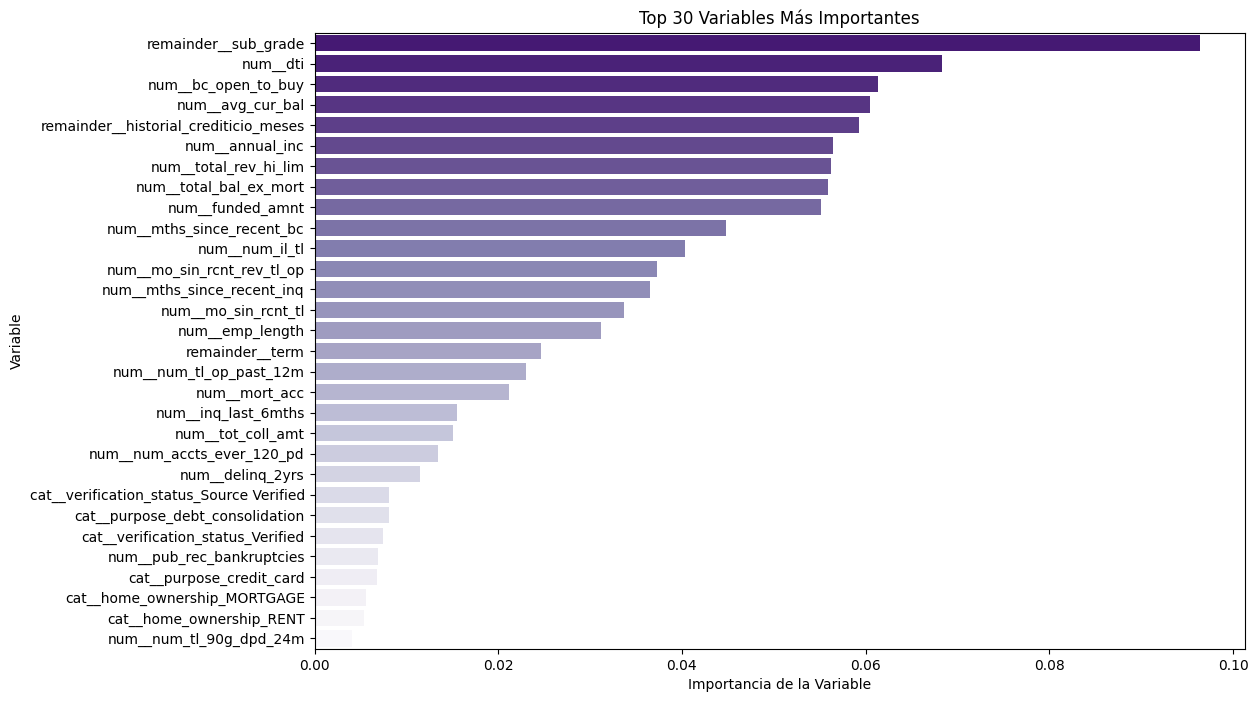

In [10]:
X = X_processed

# y es la variable objetivo
y = df_final['default']

# 2. Entrenar un modelo de Random Forest
model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Obtener los nombres de las columnas procesadas para la visualización
feature_names = preprocessor.get_feature_names_out()

# 4. Obtener y mostrar la importancia de las variables
feature_importances = pd.Series(model.feature_importances_, index=feature_names)
feature_importances = feature_importances.sort_values(ascending=False)

print("--- Importancia de las variables (ordenadas) ---")
print(feature_importances)

# Opcional: Visualizar las 20 variables más importantes
top_30_features = feature_importances.head(30)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_30_features.values, y=top_30_features.index, palette= "Purples_r")
plt.title('Top 30 Variables Más Importantes')
plt.xlabel('Importancia de la Variable')
plt.ylabel('Variable')
plt.show()

In [11]:
# Definir un umbral de importancia. Por ejemplo, 0.01
umbral_importancia = 0.01

# Seleccionar las variables que superan el umbral
variables_relevantes_seleccionadas = feature_importances[
    feature_importances > umbral_importancia
].index.tolist()


print("Variables seleccionadas con importancia > 0.01:")
print(variables_relevantes_seleccionadas)



Variables seleccionadas con importancia > 0.01:
['remainder__sub_grade', 'num__dti', 'num__bc_open_to_buy', 'num__avg_cur_bal', 'remainder__historial_crediticio_meses', 'num__annual_inc', 'num__total_rev_hi_lim', 'num__total_bal_ex_mort', 'num__funded_amnt', 'num__mths_since_recent_bc', 'num__num_il_tl', 'num__mo_sin_rcnt_rev_tl_op', 'num__mths_since_recent_inq', 'num__mo_sin_rcnt_tl', 'num__emp_length', 'remainder__term', 'num__num_tl_op_past_12m', 'num__mort_acc', 'num__inq_last_6mths', 'num__tot_coll_amt', 'num__num_accts_ever_120_pd', 'num__delinq_2yrs']


Luego de aplicar un modelo de Random Forest y seleccionar variables con importancia superior a 0.01, se identificó un conjunto robusto de variables que resultan altamente informativas para predecir el riesgo de impago. Estas variables tienen un sentido lógico y práctico, ya que representan aspectos clave del perfil financiero y comportamiento crediticio de los prestatarios.

Las variables fueron las siguientes:

**Indicadores de riesgo fundamentales:**
- `remainder__sub_grade`: El sub-grado del préstamo refleja directamente el riesgo percibido del prestatario.
- `num__dti`: La relación deuda-ingreso indica la capacidad del prestatario para asumir nueva deuda.
- `num__inq_last_6mths`: Consultas de crédito recientes pueden señalar un aumento en el riesgo de endeudamiento.

**Historial crediticio y estabilidad:**
- `remainder__historial_crediticio_meses`: La duración del historial crediticio indica estabilidad financiera.
- `num__num_accts_ever_120_pd`, `num__tot_coll_amt`, `num__delinq_2yrs`: Reflejan el historial de morosidad y cobros, predictores fuertes del riesgo futuro.
- `num__emp_length`: La antigüedad laboral sugiere estabilidad de ingresos.

**Salud financiera y liquidez:**
- `num__bc_open_to_buy` y `num__total_rev_hi_lim`: Cantidad de crédito disponible, esencial para evaluar la liquidez y capacidad de pago.
- `num__annual_inc`: Ingresos anuales como base de capacidad de pago.
- `num__funded_amnt`: Tamaño del préstamo, que impacta directamente el riesgo.

**Otras métricas relevantes:**
- Variables como `num__avg_cur_bal`, `num__total_bal_ex_mort`, `num__mths_since_recent_bc`, `num__num_il_tl`, `num__mo_sin_rcnt_rev_tl_op`, `num__mths_since_recent_inq`, `num__mo_sin_rcnt_tl`, `num__num_tl_op_past_12m`, `num__mort_acc` y `remainder__term` aportan información complementaria sobre la exposición crediticia, comportamiento reciente y estructura de la deuda.

En conjunto, este grupo de variables forma una base sólida y coherente para construir modelos de predicción de riesgo de impago, reflejando tanto la capacidad de pago como el comportamiento financiero histórico y actual del prestatario.


In [12]:
# 1. Obtener los nombres de las columnas procesadas
feature_names = preprocessor.get_feature_names_out()

# 2. Convertir X_processed a DataFrame
X_df = pd.DataFrame(X_processed, columns=feature_names)

# 3. Filtrar solo las variables importantes según tu umbral
variables_relevantes_seleccionadas = feature_importances[feature_importances > 0.01].index.tolist()
X_selected = X_df[variables_relevantes_seleccionadas]

# 4. Agregar la variable objetivo
X_selected['default'] = y.values  # Alinea índices

# 5. Guardar el DataFrame final
df_final_selected = X_selected

# Revisar
print(df_final_selected.head())



   remainder__sub_grade  num__dti  num__bc_open_to_buy  num__avg_cur_bal  \
0                  13.0 -1.108755            -0.560512          0.471897   
1                  10.0 -0.199167             3.184085         -0.216576   
2                   8.0 -0.672332            -0.478671          1.157105   
3                  25.0  0.635145            -0.357007          0.907716   
4                  12.0 -0.724308            -0.604524         -0.666832   

   remainder__historial_crediticio_meses  num__annual_inc  \
0                                  148.0        -0.303863   
1                                  192.0        -0.160853   
2                                  184.0        -0.189455   
3                                  210.0         0.403080   
4                                  338.0        -0.604184   

   num__total_rev_hi_lim  num__total_bal_ex_mort  num__funded_amnt  \
0              -0.644679               -0.883567         -1.240837   
1               2.221532            

C:\Users\David\AppData\Local\Temp\ipykernel_7640\1741641523.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected['default'] = y.values  # Alinea índices


## *División del dataset*

El desbalance de clases del dataset se abordó mediante **SMOTE**, una técnica de oversampling aplicada exclusivamente al conjunto de entrenamiento. Esto neutraliza el sesgo del modelo hacia la clase mayoritaria (no-default), permitiéndole aprender los patrones subyacentes de la clase minoritaria (default).

Para optimizar la búsqueda de hiperparámetros, se utilizó una **muestra estratificada del 10%** del conjunto de entrenamiento balanceado. Esta estrategia reduce significativamente los costos computacionales del GridSearchCV mientras se preserva la representatividad de la distribución de clases, asegurando que los hiperparámetros óptimos sean válidos para el conjunto de datos completo.

In [13]:
X = df_final_selected.drop(columns=['default'])
y = df_final_selected['default']

# División en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Proporción antes de SMOTE:", Counter(y_train))

# Aplicar SMOTE solo al conjunto de entrenamiento
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Proporción después de SMOTE:", Counter(y_train_res))

sample_size = 0.1



X_sample, _, y_sample, _ = train_test_split(
    X_train_res,
    y_train_res,
    train_size=sample_size,
    stratify=y_train_res,
    random_state=42
)

print("\nDimensiones de los datos originales después de SMOTE:")
print(f"Entrenamiento (X_train_res, y_train_res): {X_train_res.shape}")
print(f"Prueba (X_test, y_test): {X_test.shape}")

print("\nProporción en el conjunto de entrenamiento (SMOTE):")
print(y_train_res.value_counts(normalize=True))

print("\nProporción en el conjunto de prueba (original):")
print(y_test.value_counts(normalize=True))

# -------------------------------------------------------------
# Agrega esta parte para verificar las proporciones de la MUESTRA
# -------------------------------------------------------------

print("\n--- Verificación de la MUESTRA para Grid Search ---")
print(f"Dimensiones de la muestra (X_sample, y_sample): {X_sample.shape}")

print("Proporción en la MUESTRA:")
print(y_sample.value_counts(normalize=True))

Proporción antes de SMOTE: Counter({0.0: 861401, 1.0: 214847})
Proporción después de SMOTE: Counter({1.0: 861401, 0.0: 861401})

Dimensiones de los datos originales después de SMOTE:
Entrenamiento (X_train_res, y_train_res): (1722802, 22)
Prueba (X_test, y_test): (269062, 22)

Proporción en el conjunto de entrenamiento (SMOTE):
default
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Proporción en el conjunto de prueba (original):
default
0.0    0.800373
1.0    0.199627
Name: proportion, dtype: float64

--- Verificación de la MUESTRA para Grid Search ---
Dimensiones de la muestra (X_sample, y_sample): (172280, 22)
Proporción en la MUESTRA:
default
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


## *Modelado*


--- Iniciando Búsqueda de Hiperparámetros con GridSearchCV en la muestra ---
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Iteration 1, loss = 0.66888260
Validation score: 0.654458
Iteration 2, loss = 0.63843885
Validation score: 0.655851
Iteration 3, loss = 0.64232113
Validation score: 0.644590
Iteration 4, loss = 0.63485456
Validation score: 0.639424
Iteration 5, loss = 0.62981772
Validation score: 0.630253
Iteration 6, loss = 0.63198385
Validation score: 0.636522
Iteration 7, loss = 0.63032680
Validation score: 0.649698
Iteration 8, loss = 0.62713756
Validation score: 0.662120
Iteration 9, loss = 0.62441952
Validation score: 0.661772
Iteration 10, loss = 0.62224506
Validation score: 0.649234
Iteration 11, loss = 0.62157135
Validation score: 0.661481
Iteration 12, loss = 0.61815703
Validation score: 0.651614
Iteration 13, loss = 0.61723404
Validation score: 0.654690
Iteration 14, loss = 0.61754857
Validation score: 0.664093
Iteration 15, loss = 0.61712831
Validation 

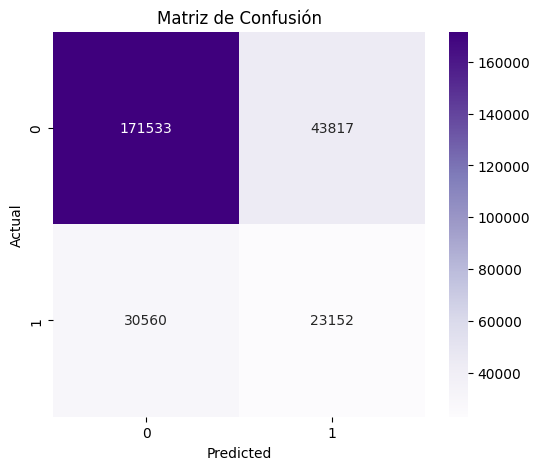

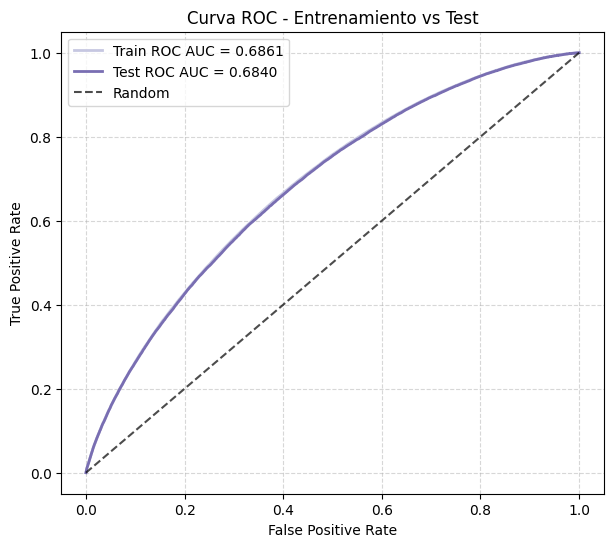

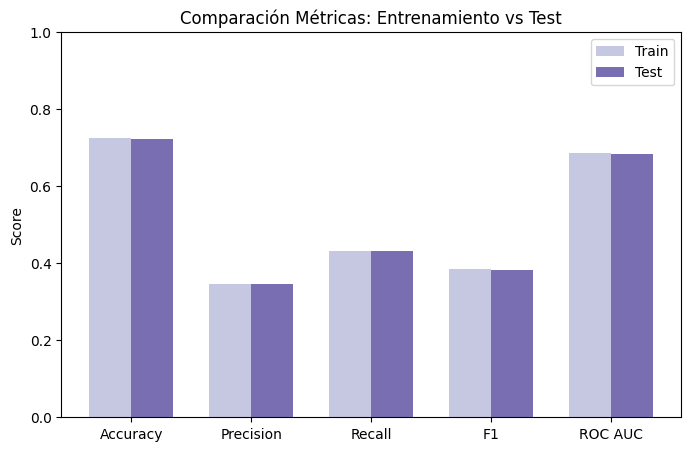

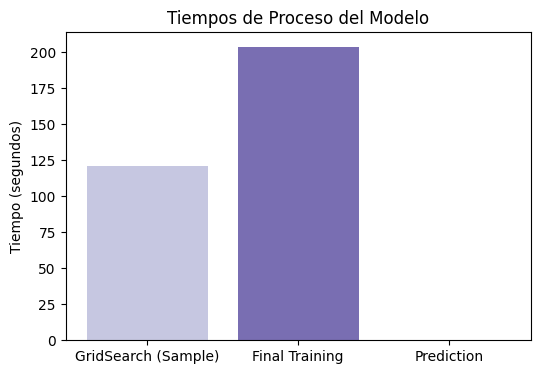

In [14]:
# 2. Definir modelo y GridSearchCV

mlp = MLPClassifier(random_state=42, early_stopping=True, verbose=True)

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [300, 500, 1000]
}

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)


# 3. Entrenar y medir tiempo de la búsqueda de hiperparámetros en la muestra
print("\n--- Iniciando Búsqueda de Hiperparámetros con GridSearchCV en la muestra ---")
start_time_grid = time.time()
grid_search.fit(X_sample, y_sample)
training_time_grid = time.time() - start_time_grid
print(f"\nTiempo de búsqueda de hiperparámetros: {training_time_grid:.2f} segundos")

# Obtener los mejores hiperparámetros de la búsqueda en la muestra
best_params = grid_search.best_params_
print("\nMejores hiperparámetros encontrados en la muestra:")
print(best_params)

# 4. Entrenar el modelo final con los mejores hiperparámetros y el conjunto de datos completo
print("\n--- Entrenando el modelo final en el conjunto de datos completo ---")
best_model = MLPClassifier(random_state=42, **best_params, early_stopping=True, verbose=True)
start_time_final = time.time()
best_model.fit(X_train_res, y_train_res)
training_time_final = time.time() - start_time_final
print(f"Tiempo de entrenamiento del modelo final: {training_time_final:.2f} segundos")

# 5. Predicciones y métricas
start_time_pred = time.time()
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]
prediction_time = time.time() - start_time_pred
print(f"Tiempo de predicción en test: {prediction_time:.2f} segundos")

y_pred_train = best_model.predict(X_train)
y_proba_train = best_model.predict_proba(X_train)[:, 1]

# Métricas entrenamiento
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)

print("\n--- Métricas en Entrenamiento ---")
print(f"Accuracy: {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall: {rec_train:.4f}")
print(f"F1-score: {f1_train:.4f}")
print(f"ROC AUC: {roc_auc_train:.4f}")

# Métricas test
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

print("\n--- Métricas en Test ---")
print(f"Accuracy: {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall: {rec_test:.4f}")
print(f"F1-score: {f1_test:.4f}")
print(f"ROC AUC: {roc_auc_test:.4f}")

# 6. Gráficos de evaluación
colors = sns.color_palette("Purples", 2)
colors_times = sns.color_palette("Purples", 2)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

# Curva ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)
plt.figure(figsize=(7, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC AUC = {roc_auc_train:.4f}', color=colors[0], linewidth=2)
plt.plot(fpr_test, tpr_test, label=f'Test ROC AUC = {roc_auc_test:.4f}', color=colors[1], linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Entrenamiento vs Test')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Comparación de métricas
metrics_train = [acc_train, prec_train, rec_train, f1_train, roc_auc_train]
metrics_test = [acc_test, prec_test, rec_test, f1_test, roc_auc_test]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
plt.figure(figsize=(8, 5))
bar_width = 0.35
x = np.arange(len(metric_names))
plt.bar(x, metrics_train, width=bar_width, label='Train', color=colors[0])
plt.bar(x + bar_width, metrics_test, width=bar_width, label='Test', color=colors[1])
plt.xticks(x + bar_width / 2, metric_names)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Comparación Métricas: Entrenamiento vs Test')
plt.legend()
plt.show()

# Comparación de tiempos
plt.figure(figsize=(6, 4))
plt.bar(['GridSearch (Sample)', 'Final Training', 'Prediction'], [training_time_grid, training_time_final, prediction_time], color=colors_times)
plt.ylabel('Tiempo (segundos)')
plt.title('Tiempos de Proceso del Modelo')
plt.show()

El modelo desarrollado es una **solución efectiva** para la predicción de impagos, priorizando la detección de riesgo sobre la precisión absoluta.

El modelo MLP, optimizado con *SMOTE*, demuestra un poder predictivo bueno (ROC AUC de 0.68), superando la capacidad de una predicción aleatoria. Su mayor fortaleza es un **recall de ~43%**, lo que le permite identificar a casi la mitad de los clientes de alto riesgo. Esto es fundamental en finanzas, donde el costo de un impago no detectado es mayor que el de rechazar a un cliente solvente.

Además, el modelo es robusto y generalizable, ya que muestra un rendimiento consistente entre los conjuntos de entrenamiento y prueba sin sobreajuste. En resumen, este modelo establece una base sólida y valiosa para un sistema de alerta de riesgo crediticio, sentando las bases para futuras optimizaciones.



# **LIME**

In [15]:
from IPython.display import display, HTML
import lime
import lime.lime_tabular

# --- 1. Asegurar que X_test tenga nombres de columnas ---
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=variables_relevantes_seleccionadas)

# --- 2. Encontrar ejemplos mal clasificados ---
misclassified_idx = np.where(y_pred_test != y_test)[0]
print(f"Se encontraron {len(misclassified_idx)} observaciones mal clasificadas.")

# Elegir la primera mal clasificada (puedes cambiar el índice)
i = misclassified_idx[0]
print("Índice seleccionado:", i)
print("Etiqueta real:", y_test.iloc[i])
print("Predicción modelo:", y_pred_test[i])

# --- 3. Crear el explicador LIME ---
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_res),
    feature_names=variables_relevantes_seleccionadas,
    class_names=["Fully Paid", "Default"],
    mode="classification"
)

# --- 4. Explicar la predicción de esa instancia ---
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=best_model.predict_proba
)

Se encontraron 74377 observaciones mal clasificadas.
Índice seleccionado: 3
Etiqueta real: 0.0
Predicción modelo: 1.0


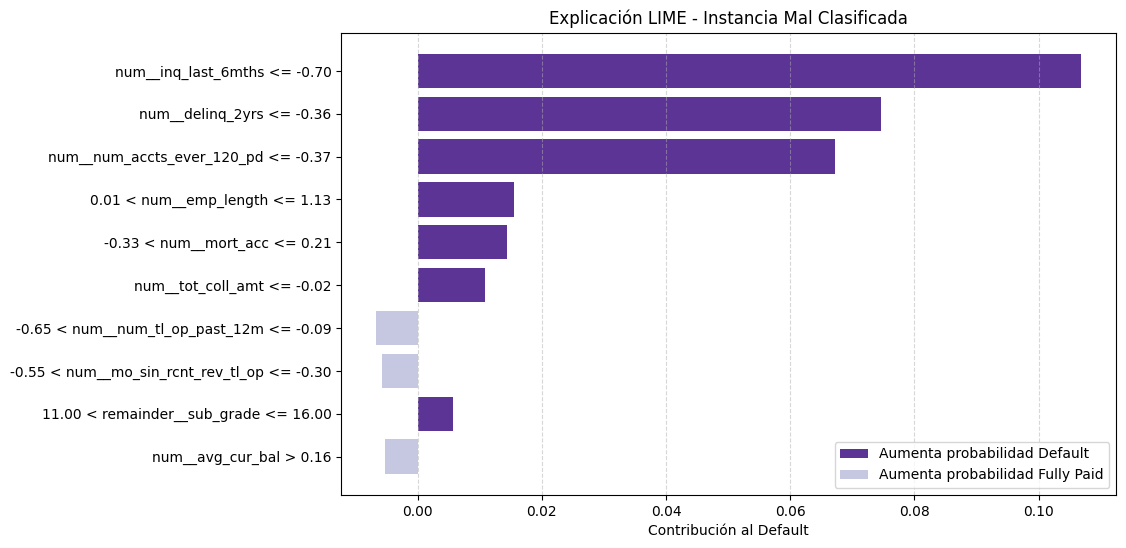

In [16]:
# --- 1. Extraer contribuciones de LIME ---
exp_list = exp.as_list()  # [(feature, contrib), ...]
features, contributions = zip(*exp_list)
contributions = np.array(contributions)

# --- 2. Asignar colores por clase usando Purples ---
purple_palette = sns.color_palette("Purples", 5)  # 5 tonos de morado
colors = [purple_palette[4] if c > 0 else purple_palette[1] for c in contributions]
# purple_palette[4] = oscuro (Default), purple_palette[1] = claro (Fully Paid)

# --- 3. Graficar ---
plt.figure(figsize=(10, 6))
plt.barh(features, contributions, color=colors)
plt.xlabel('Contribución al Default')
plt.title('Explicación LIME - Instancia Mal Clasificada')

# Invertir eje para poner la característica más importante arriba
plt.gca().invert_yaxis()

# Crear leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=purple_palette[4], label='Aumenta probabilidad Default'),
                   Patch(facecolor=purple_palette[1], label='Aumenta probabilidad Fully Paid')]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

La visualización muestra la explicación generada por LIME para una instancia mal clasificada por el modelo. Cada barra representa la contribución de una característica específica a la predicción de **Default** o **Fully Paid**. Las barras en morado oscuro indican características que aumentan la probabilidad de Default, mientras que las barras en morado claro representan características que favorecen la probabilidad de pago completo (Fully Paid). Se observa que variables como `num_inq_last_6mths`, `num_accts_ever_120_pd` y `num_delinq_2yrs` ejercen la mayor influencia hacia Default, mientras que algunas otras características tienen efectos menores en la dirección opuesta. Esta representación permite interpretar de manera clara cómo cada característica individual contribuye a la decisión del modelo, facilitando la identificación de los factores que llevan a una predicción de riesgo de impago.